# Transaction Anomaly Detection — Isolation Forest

Clean Google Colab implementation using the **Kaggle Credit Card Fraud Detection** dataset.

The `Class` column is used **only for evaluation**. It is never passed to Isolation Forest during training.


## 1. Install dependencies


In [29]:
!pip -q install kagglehub scikit-learn pandas numpy matplotlib seaborn joblib


## 2. Imports and configuration


In [30]:
import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 3. Download the Kaggle dataset

Dataset: `mlg-ulb/creditcardfraud`

It contains anonymized credit-card transactions and a `Class` label where `0` is legitimate and `1` is fraud.

In [31]:
import kagglehub

dataset_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
print('Downloaded to:', dataset_path)

csv_files = glob.glob(os.path.join(dataset_path, '**', 'creditcard.csv'), recursive=True)
if not csv_files:
    csv_files = glob.glob(os.path.join(dataset_path, '**', '*.csv'), recursive=True)

if not csv_files:
    raise FileNotFoundError('creditcard.csv was not found.')

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print('File:', csv_path)
print('Shape:', df.shape)
display(df.head())


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Downloaded to: /kaggle/input/creditcardfraud
File: /kaggle/input/creditcardfraud/creditcard.csv
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Basic dataset analysis


In [32]:
print('Columns:')
print(df.columns.tolist())

print('\nMissing values:')
print(df.isnull().sum().sum())

print('\nClass distribution:')
print(df['Class'].value_counts())
print('\nClass percentage:')
print((df['Class'].value_counts(normalize=True) * 100).round(4))


Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values:
0

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentage:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


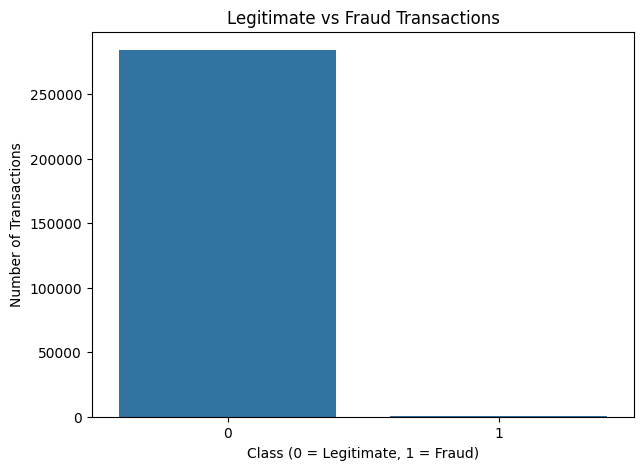

In [33]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df)
plt.title('Legitimate vs Fraud Transactions')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.show()


## 5. Prepare features

Isolation Forest is an **unsupervised** model. Therefore, `Class` is explicitly removed from the training features.

`Time`, `Amount`, and the anonymized `V1`–`V28` features are used as inputs.

In [34]:
from sklearn.model_selection import train_test_split

TARGET = 'Class'

feature_columns = [c for c in df.columns if c.startswith('V')]
feature_columns += ['Time', 'Amount']

# Split data into features (X) and target (y)
X = df[feature_columns].copy()
y = df[TARGET].astype(int).copy()

# Perform train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3, # 30% for testing
    random_state=RANDOM_STATE,
    stratify=y # Stratify to maintain class distribution in splits
)

print('Number of features:', len(feature_columns))
print('Features:', feature_columns)
print(f'Training set shape: {X_train_raw.shape}, Fraud: {y_train.sum()}')
print(f'Test set shape: {X_test_raw.shape}, Fraud: {y_test.sum()}')

Number of features: 30
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Time', 'Amount']
Training set shape: (199364, 30), Fraud: 344
Test set shape: (85443, 30), Fraud: 148


In [35]:
# Scale numerical features
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print('Training matrix shape:', X_train_scaled.shape)
print('Test matrix shape:', X_test_scaled.shape)

# Convert scaled arrays back to DataFrames for easier handling with column names
X_train = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train_raw.index)
X_test = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test_raw.index)

Training matrix shape: (199364, 30)
Test matrix shape: (85443, 30)


## 6. Train Isolation Forest

The dataset has a very small fraud percentage. We start with `contamination=0.002`, close to the actual fraud proportion, and later test multiple values.

In [36]:
# Using 'auto' contamination to let Isolation Forest estimate it, or set a small initial value.
# We will tune the decision threshold later based on anomaly scores.
model = IsolationForest(
    n_estimators=200,
    contamination='auto',
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train the model on the scaled training data
model.fit(X_train)

# Generate continuous anomaly scores for both training and test sets
anomaly_score_train = -model.decision_function(X_train)
anomaly_score_test = -model.decision_function(X_test)

print('Anomaly scores generated for training and test sets.')

Anomaly scores generated for training and test sets.


## 7. Evaluate the model

Accuracy is included for completeness, but it is **not the primary metric** because this dataset is extremely imbalanced. Precision, recall, F1 and PR-AUC are more informative.

In [37]:
# The model.predict method returns 1 for inliers (normal) and -1 for outliers (anomalies).
# Convert to 0 for normal and 1 for anomalies.
y_pred_test = (model.predict(X_test) == -1).astype(int)

precision = precision_score(y_test, y_pred_test, zero_division=0)
recall = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)
pr_auc = average_precision_score(y_test, anomaly_score_test)
roc_auc = roc_auc_score(y_test, anomaly_score_test)

print('Evaluation on Test Set:')
print('Precision :', round(precision, 4))
print('Recall    :', round(recall, 4))
print('F1 Score  :', round(f1, 4))
print('PR-AUC    :', round(pr_auc, 4))
print('ROC-AUC   :', round(roc_auc, 4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_test, digits=4, zero_division=0))

Evaluation on Test Set:
Precision : 0.0355
Recall    : 0.7905
F1 Score  : 0.068
PR-AUC    : 0.1584
ROC-AUC   : 0.9437

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9627    0.9808     85295
           1     0.0355    0.7905    0.0680       148

    accuracy                         0.9624     85443
   macro avg     0.5176    0.8766    0.5244     85443
weighted avg     0.9980    0.9624    0.9793     85443



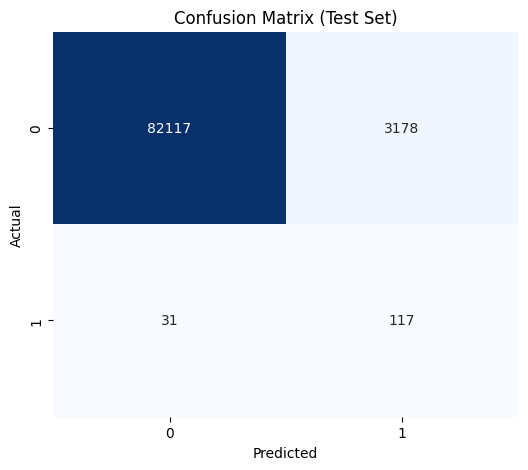

In [38]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.show()

## 8. Tune contamination

Instead of arbitrarily choosing one contamination value, test several values and select one based on the metric that matters most for fraud detection.

In [39]:
contamination_values = [0.001, 0.0015, 0.002, 0.0025, 0.003, 0.005, 0.01]
tuning_results = []

for contamination in contamination_values:
    temp_model = IsolationForest(
        n_estimators=200,
        contamination=contamination, # Use the current contamination value
        max_samples='auto',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    # Train on the training data
    temp_model.fit(X_train)

    # Predict and score on the test data
    temp_pred_test = (temp_model.predict(X_test) == -1).astype(int)
    temp_score_test = -temp_model.decision_function(X_test)

    tuning_results.append({
        'contamination': contamination,
        'precision': precision_score(y_test, temp_pred_test, zero_division=0),
        'recall': recall_score(y_test, temp_pred_test, zero_division=0),
        'f1': f1_score(y_test, temp_pred_test, zero_division=0),
        'pr_auc': average_precision_score(y_test, temp_score_test)
    })

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df.round(4))

# Based on the tuning results, we might choose a contamination value.
# Let's pick the one that maximizes F1 score for now as a balanced metric.
optimal_contamination = tuning_df.loc[tuning_df['f1'].idxmax()]['contamination']
print(f'Optimal contamination (based on F1 score): {optimal_contamination}')

,contamination,precision,recall,f1,pr_auc
0,0.0010,0.3333,0.1959,0.2468,0.1584
1,0.0015,0.3070,0.2365,0.2672,0.1584
2,0.0020,0.2293,0.2432,0.2361,0.1584
3,0.0025,0.2199,0.2838,0.2478,0.1584
4,0.0030,0.1875,0.3041,0.2320,0.1584
5,0.0050,0.1471,0.3986,0.2149,0.1584
6,0.0100,0.1012,0.5743,0.1721,0.1584


Optimal contamination (based on F1 score): 0.0015


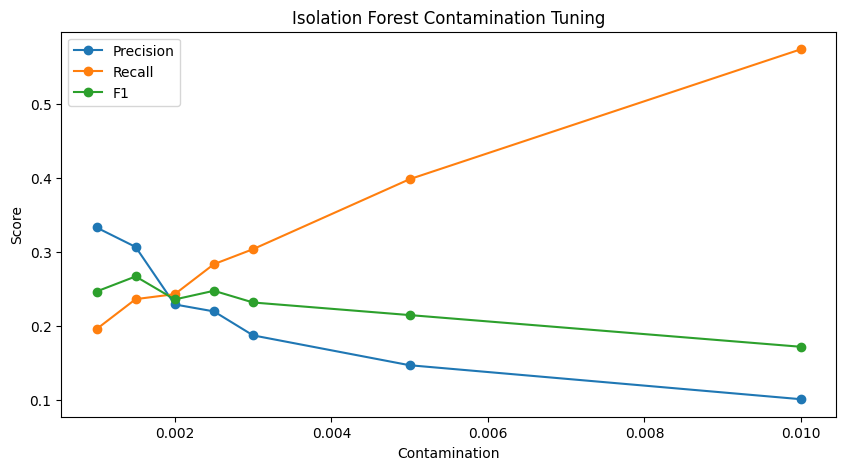

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(tuning_df['contamination'], tuning_df['precision'], marker='o', label='Precision')
plt.plot(tuning_df['contamination'], tuning_df['recall'], marker='o', label='Recall')
plt.plot(tuning_df['contamination'], tuning_df['f1'], marker='o', label='F1')
plt.xlabel('Contamination')
plt.ylabel('Score')
plt.title('Isolation Forest Contamination Tuning')
plt.legend()
plt.show()


## 9. Tune Decision Threshold

,threshold,precision,recall,f1,pr_auc
0,-0.1492,0.0017,1.0000,0.0035,0.1584
1,-0.1452,0.0017,1.0000,0.0035,0.1584
2,-0.1412,0.0018,1.0000,0.0035,0.1584
3,-0.1372,0.0018,1.0000,0.0037,0.1584
4,-0.1332,0.0019,0.9932,0.0038,0.1584
...,...,...,...,...,...
95,0.2313,0.2857,0.0135,0.0258,0.1584
96,0.2354,0.3333,0.0135,0.0260,0.1584
97,0.2394,0.4000,0.0135,0.0261,0.1584
98,0.2434,0.0000,0.0000,0.0000,0.1584


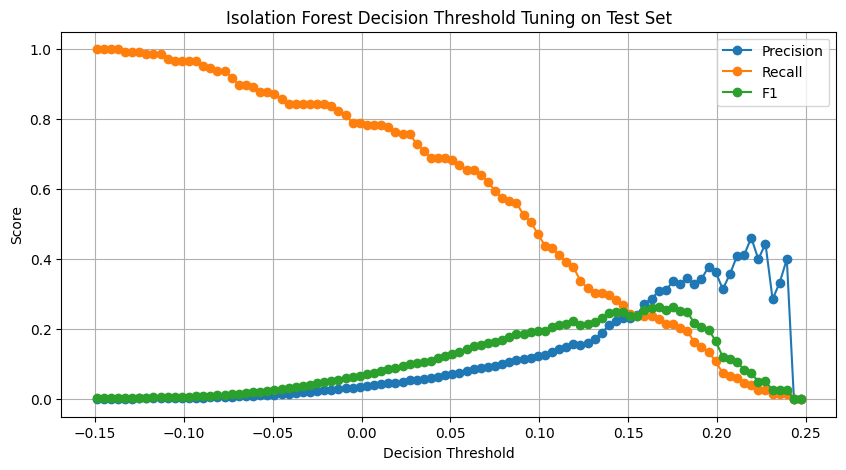

Optimal decision threshold (based on F1 score): 0.1673

Final Evaluation on Test Set with Optimal Threshold:
Precision : 0.3091
Recall    : 0.2297
F1 Score  : 0.2636
PR-AUC    : 0.1584
ROC-AUC   : 0.9437

Final Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.9987    0.9991    0.9989     85295
           1     0.3091    0.2297    0.2636       148

    accuracy                         0.9978     85443
   macro avg     0.6539    0.6144    0.6312     85443
weighted avg     0.9975    0.9978    0.9976     85443



In [41]:
threshold_values = np.linspace(anomaly_score_test.min(), anomaly_score_test.max(), 100)
decision_threshold_results = []

for threshold in threshold_values:
    # Classify as anomaly if score > threshold
    y_pred_threshold = (anomaly_score_test > threshold).astype(int)

    decision_threshold_results.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_threshold, zero_division=0),
        'recall': recall_score(y_test, y_pred_threshold, zero_division=0),
        'f1': f1_score(y_test, y_pred_threshold, zero_division=0),
        'pr_auc': average_precision_score(y_test, anomaly_score_test) # PR-AUC is independent of threshold
    })

decision_threshold_df = pd.DataFrame(decision_threshold_results)
display(decision_threshold_df.round(4))

# Visualize the trade-off
plt.figure(figsize=(10, 5))
plt.plot(decision_threshold_df['threshold'], decision_threshold_df['precision'], marker='o', label='Precision')
plt.plot(decision_threshold_df['threshold'], decision_threshold_df['recall'], marker='o', label='Recall')
plt.plot(decision_threshold_df['threshold'], decision_threshold_df['f1'], marker='o', label='F1')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Isolation Forest Decision Threshold Tuning on Test Set')
plt.legend()
plt.grid(True)
plt.show()

# Select optimal threshold (e.g., maximizing F1 score)
optimal_threshold = decision_threshold_df.loc[decision_threshold_df['f1'].idxmax()]['threshold']
print(f'Optimal decision threshold (based on F1 score): {optimal_threshold:.4f}')

# Apply the optimal threshold to get final test predictions
y_pred_test_optimal = (anomaly_score_test > optimal_threshold).astype(int)

print('\nFinal Evaluation on Test Set with Optimal Threshold:')
print('Precision :', round(precision_score(y_test, y_pred_test_optimal, zero_division=0), 4))
print('Recall    :', round(recall_score(y_test, y_pred_test_optimal, zero_division=0), 4))
print('F1 Score  :', round(f1_score(y_test, y_pred_test_optimal, zero_division=0), 4))
print('PR-AUC    :', round(average_precision_score(y_test, anomaly_score_test), 4))
print('ROC-AUC   :', round(roc_auc_score(y_test, anomaly_score_test), 4))

print('\nFinal Classification Report (Test Set):')
print(classification_report(y_test, y_pred_test_optimal, digits=4, zero_division=0))

## 9. Inspect suspicious transactions


In [42]:
test_results = X_test_raw.copy()
test_results['Class'] = y_test
test_results['anomaly_score'] = anomaly_score_test
test_results['predicted_anomaly'] = y_pred_test_optimal

suspicious = test_results.sort_values('anomaly_score', ascending=False).head(20)
display(suspicious[['Time', 'Amount', 'Class', 'anomaly_score', 'predicted_anomaly']])

,Time,Amount,Class,anomaly_score,predicted_anomaly
173353,121450.0,4861.64,0,0.247373,1
220090,142019.0,5964.95,0,0.243425,1
154234,100924.0,1.00,1,0.242320,1
153823,100223.0,2.28,1,0.239970,1
176335,122723.0,1676.60,0,0.239543,1
46841,42951.0,12910.93,0,0.239288,1
228158,145381.0,8182.70,0,0.232438,1
153835,100298.0,1.00,1,0.229974,1
151008,94362.0,1.00,1,0.229131,1
138706,82802.0,305.25,0,0.223808,1


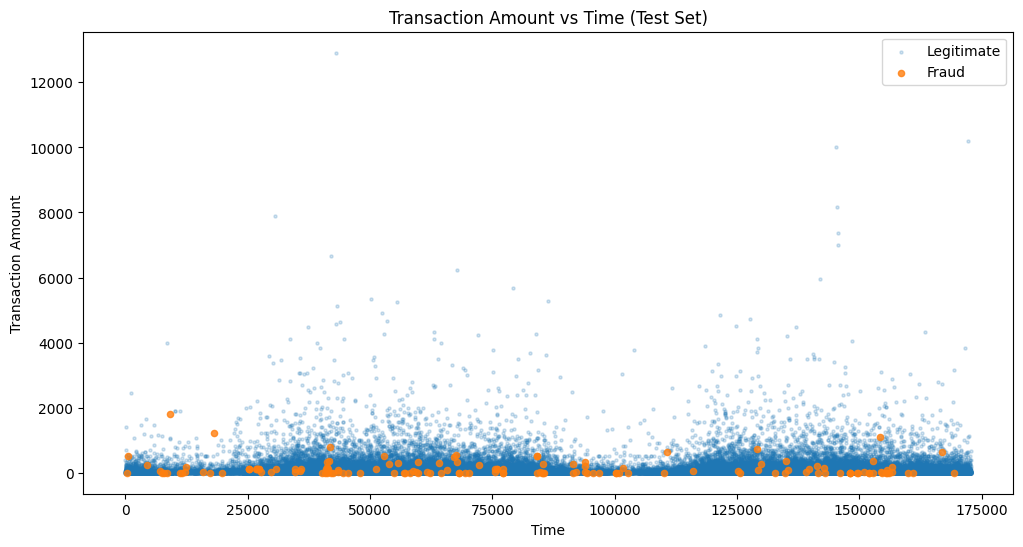

In [43]:
plt.figure(figsize=(12, 6))
normal_test = test_results[test_results['Class'] == 0]
fraud_test = test_results[test_results['Class'] == 1]

plt.scatter(normal_test['Time'], normal_test['Amount'], s=5, alpha=0.2, label='Legitimate')
plt.scatter(fraud_test['Time'], fraud_test['Amount'], s=20, alpha=0.8, label='Fraud')
plt.xlabel('Time')
plt.ylabel('Transaction Amount')
plt.title('Transaction Amount vs Time (Test Set)')
plt.legend()
plt.show()

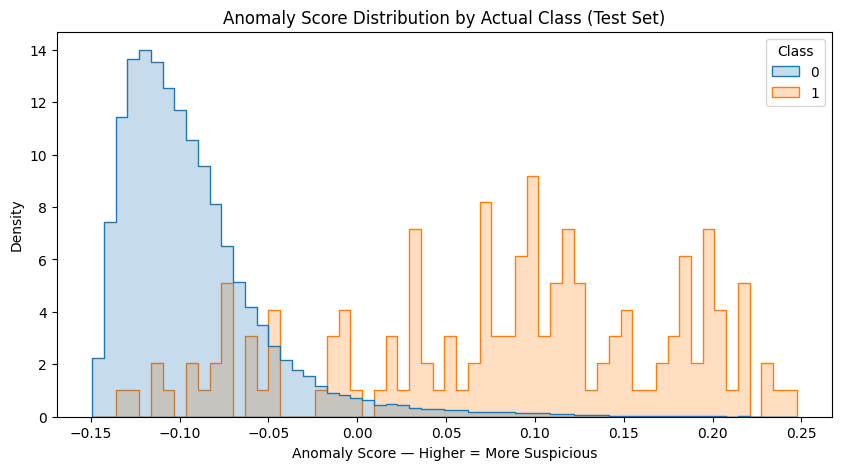

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(data=test_results, x='anomaly_score', hue='Class', bins=60, element='step', stat='density', common_norm=False)
plt.xlabel('Anomaly Score — Higher = More Suspicious')
plt.title('Anomaly Score Distribution by Actual Class (Test Set)')
plt.show()

## 10. Save model for WealthWise

The model and scaler are saved separately so the same preprocessing can be applied when new WealthWise transactions are scored.

In [45]:
os.makedirs('models', exist_ok=True)

joblib.dump(model, 'models/transaction_anomaly_isolation_forest.pkl')
joblib.dump(scaler, 'models/transaction_anomaly_scaler.pkl')
joblib.dump(feature_columns, 'models/transaction_anomaly_features.pkl')
joblib.dump(optimal_threshold, 'models/transaction_anomaly_optimal_threshold.pkl')

print('Saved:')
print('models/transaction_anomaly_isolation_forest.pkl')
print('models/transaction_anomaly_scaler.pkl')
print('models/transaction_anomaly_features.pkl')
print('models/transaction_anomaly_optimal_threshold.pkl')

Saved:
models/transaction_anomaly_isolation_forest.pkl
models/transaction_anomaly_scaler.pkl
models/transaction_anomaly_features.pkl
models/transaction_anomaly_optimal_threshold.pkl


In [46]:
# Save detected anomalies for inspection
results[results['predicted_anomaly'] == 1].sort_values('anomaly_score', ascending=False).to_csv(
    'detected_transaction_anomalies.csv', index=False
)
print('Saved detected_transaction_anomalies.csv')


Saved detected_transaction_anomalies.csv


## 11. Final takeaway

Isolation Forest is trained without the `Class` column, making this a genuine unsupervised anomaly-detection workflow. The fraud label is used only after prediction to benchmark how well the detected anomalies correspond to known fraud.

For WealthWise production, the next step is to replace the anonymized `V1`–`V28` features with user-specific financial features such as amount deviation, merchant frequency, category spending deviation, transaction frequency, and transaction timing.